In [3]:
import scanpy as sc
import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import warnings
import palava

import json
#import statsmodels.api as sm
from scipy.stats import spearmanr

import sys
import os
import seaborn as sns
import gc
from palava import settings
import matplotlib.patches as mpatches
import time 
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib
from scipy.ndimage import median_filter
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph
import igraph as ig
#import leidenalg as la
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
import copy

In [44]:

def pathways_with(markers):    
    result = analysis.identifiers(ids=markers,page_size='-1', page='-1',p_value =1)
    token = result['summary']['token']
    str_ = markers + ' \n '
    for path_n in [path['name'] for path in result['pathways']]:
        str_ +='    ' + path_n + ' \n '
    return str_ 


# Helper functions for the plots
def sort_based_on_first_row(matrix):
    sorted_indices = np.argsort(-matrix[0])
    # Rearrange the columns based on the sorted indices
    sorted_matrix = matrix[:, sorted_indices]
    return  sorted_matrix


def plot_gene_expression_boxplot(adata, gene_symbol, order = None, cell_labels = 'cell.labels'):
    # Check if the gene symbol is in adata.var.index
    if gene_symbol not in adata.var.index:
        raise ValueError(f"Gene symbol '{gene_symbol}' not found in adata.var.index.")
    
    # Extract gene expression data for the specified gene
    gene_expression = adata[:, gene_symbol].X
    
    # Ensure that gene_expression is a 1D array
    if gene_expression.ndim > 1:
        gene_expression = gene_expression.toarray().flatten()  # For sparse matrices
    
    # Create a DataFrame with expression data and corresponding cell labels
    df = pd.DataFrame({
        'Gene Expression': gene_expression,
        'Cell Label': adata.obs[cell_labels]
    })
    if order is None:
        order = list(set(adata.obs[cell_labels].values))
    
    # Plot the boxplot using seaborn
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Cell Label', y='Gene Expression', data=df, order=order)
    plt.title(f'Gene Expression Boxplot for {gene_symbol}')
    plt.xticks(rotation=90)
    plt.show()
    plt.close()

def plot_pca(adata, color_by='cell.labels', n_pcs=2):
    """
    This function computes and plots a PCA scatter plot from an AnnData object.
    
    Parameters:
    - adata: AnnData object
    - color_by: Column name in adata.obs to color the plot by (default: 'cell.labels')
    - n_pcs: Number of principal components to compute (default: 2)
    """
    # Check if PCA has already been computed, if not, compute PCA
    if 'X_pca' not in adata.obsm:
        sc.tl.pca(adata, n_comps=n_pcs)
    
    # Create the PCA plot, colored by the specified observation (e.g., cell labels)
    sc.pl.pca(adata, color=color_by, components=[1, 2], title="PCA Plot")


def scatter_plot_grid(data, dim_pairs, ncols=3, label_array=None, palette='tab20', point_size=5.0, title=None):
    """
    Creates a grid of scatter plots based on dimension pairs with a legend for discrete labels.

    Parameters:
        data (np.ndarray): NumPy array with dimensions (dimensions, samples).
        dim_pairs (list of str): List of dimension pairs as strings, e.g., ['1,2', '8,6'].
        ncols (int): Number of columns in the grid.
        label_array (np.ndarray or None): Discrete labels for samples (length must match samples in data).
        palette (str): Color palette for the labels.
        point_size (float): Size of the points in the scatter plots.
        title (str): Title for the grid of scatter plots.
    """
    # Parse dimension pairs into a list of tuples
    dim_pairs = [tuple(map(int, pair.split(','))) for pair in dim_pairs]
    nplots = len(dim_pairs)
    nrows = int(np.ceil(nplots / ncols))  # Determine the number of rows

    # Create a grid of subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5))
    axes = axes.flatten()  # Flatten axes array for easier indexing

    for idx, (x_dim, y_dim) in enumerate(dim_pairs):
        ax = axes[idx]

        # Scatter plot for each pair of dimensions
        scatter_df = pd.DataFrame({
            f"Dimension {x_dim}": data[x_dim, :],
            f"Dimension {y_dim}": data[y_dim, :],
            "Label": label_array if label_array is not None else None
        })

        sns.scatterplot(
            data=scatter_df,
            x=f"Dimension {x_dim}",
            y=f"Dimension {y_dim}",
            hue="Label" if label_array is not None else None,
            palette=palette,
            s=point_size,
            ax=ax
        )
        x_label = axis_names_dict.get(x_dim, f"Dimension {x_dim}") if axis_names_dict else f"Dimension {x_dim}"
        y_label = axis_names_dict.get(y_dim, f"Dimension {y_dim}") if axis_names_dict else f"Dimension {y_dim}"
        ax.set_xlabel(x_label, fontsize  =15)
        ax.set_ylabel(y_label, fontsize  =15)
       
        if label_array is not None:
            ax.legend_.remove()  # Remove legend from individual plots

    # Turn off unused axes
    for idx in range(len(dim_pairs), len(axes)):
        axes[idx].axis('off')

    # Add a title
    if title:
        fig.suptitle(title, y=1.02, fontsize=16)

    # Add a custom legend
    if label_array is not None:
        unique_labels = np.unique(label_array)
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=len(unique_labels)/2,  fontsize  =11, markerscale =3.5, bbox_to_anchor=(0.5, -0.2))

    plt.tight_layout()
    plt.show()
    

In [4]:


adata = sc.read('data/mouse_pancreas_delta.h5ad') 
pathways = [torch.tensor(i) for i in adata.uns['pathways_5000hvg']]

adata.X= adata.X.todense()
adata.X= np.array(adata.X)

In [5]:
num_unann = int(40)

pathway_names = adata.uns['pathway_names']
num_ann = pathway_names.shape[0]
pathway_names_plot = [pathway_names[i].replace('_', ' ' ).capitalize() + ' ['+str(i)+']'  for i in range(len(pathway_names))] + ['Unannotated factor '+ str(i + 1) + ' ['+str(i+num_ann)+']'  for i in range(num_unann)]



In [6]:
cluster_counts = adata.obs['clusters_fine'].value_counts()
print(cluster_counts)

clusters_fine
Ductal           916
Ngn3 high EP     642
Fev+ Beta        452
Beta             308
Pre-Beta         283
Alpha            263
Ngn3 low EP      262
Pre-Alpha        218
Epsilon          142
Delta             70
Fev+ Delta        51
Fev+ Epsilon      46
Fev+ Pyy          32
Fev+ Alpha         6
Pre-endocrine      5
Name: count, dtype: int64


In [7]:
gene_names = adata.var
num_genes = len(adata.var)

pathways_bool = pathways
path_uann =  torch.zeros(num_genes)

pathways_bool += [path_uann] * num_unann


In [8]:
SCVI_palava = palava.model.SCVI_palava
SCVI_palava.setup_anndata(adata, layer = 'counts')

/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


In [49]:
dr = 'saved_models/small_lr_seed=1_lambda=0.5_lambda_marker_genes=0.1_palava_width=25_list_of_nonlin_factors=none'


In [52]:
scvi_palava = SCVI_palava.load(dr+'/latent_and_slope_data/scvi_model', adata)


/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:168: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /home/ssanthoshkum/.local/lib/python3.10/site-pa ...
  rank_zero_warn(
/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/site-packages/palava/model/base/_utils.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipp

Number of latent variables = 94: 54 annotated + 40 unannotated


In [53]:
adata.obsm["X_scVI"] = scvi_palava.get_latent_representation()

In [54]:
latent = adata.obsm["X_scVI"][:,:(num_ann + num_unann)]
learned_activations = np.transpose(latent)

In [55]:
ind_sort = np.argsort(adata.obs['clusters_fine'].values)

In [56]:


med_libsize = np.median(np.sum(adata.X, axis = 1))
print("Median library size is " + str(med_libsize))
adata_norm = sc.pp.normalize_per_cell(adata, counts_per_cell_after = med_libsize, copy = True)
adata_norm = sc.pp.log1p(adata_norm, copy = True)

sc.tl.pca(adata_norm, n_comps=50)

Median library size is 1180.0


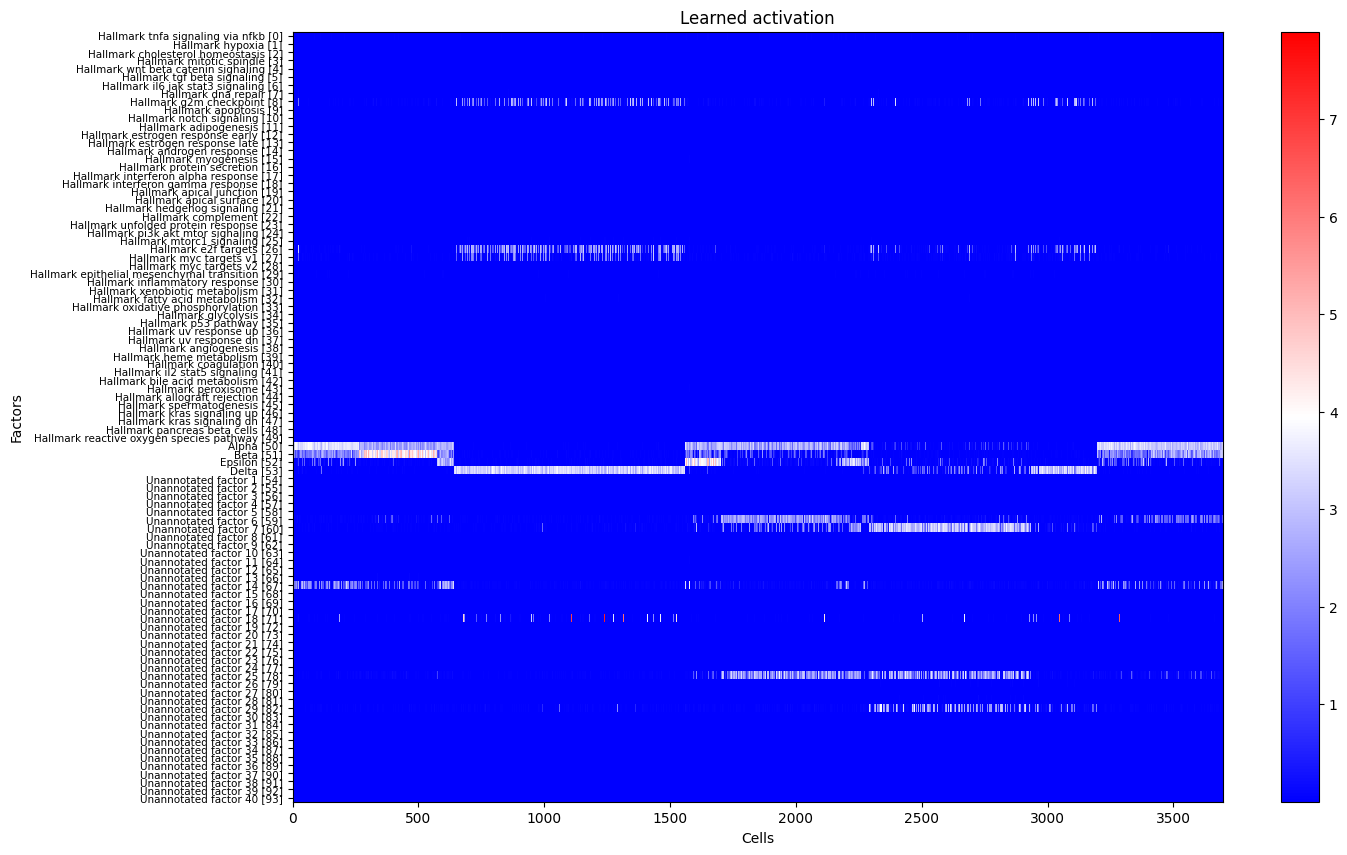

In [57]:

plt.figure(figsize=(15, 10))
plt.imshow(learned_activations[:, ind_sort],   aspect = 'auto', cmap='bwr', interpolation = 'none', rasterized=True)
plt.title("Learned activation")
plt.xlabel('Cells')
plt.ylabel('Factors')
_ = plt.yticks([i for i in range(len(pathway_names_plot))], pathway_names_plot, fontsize = 7.5)
cbar = plt.colorbar()

[]


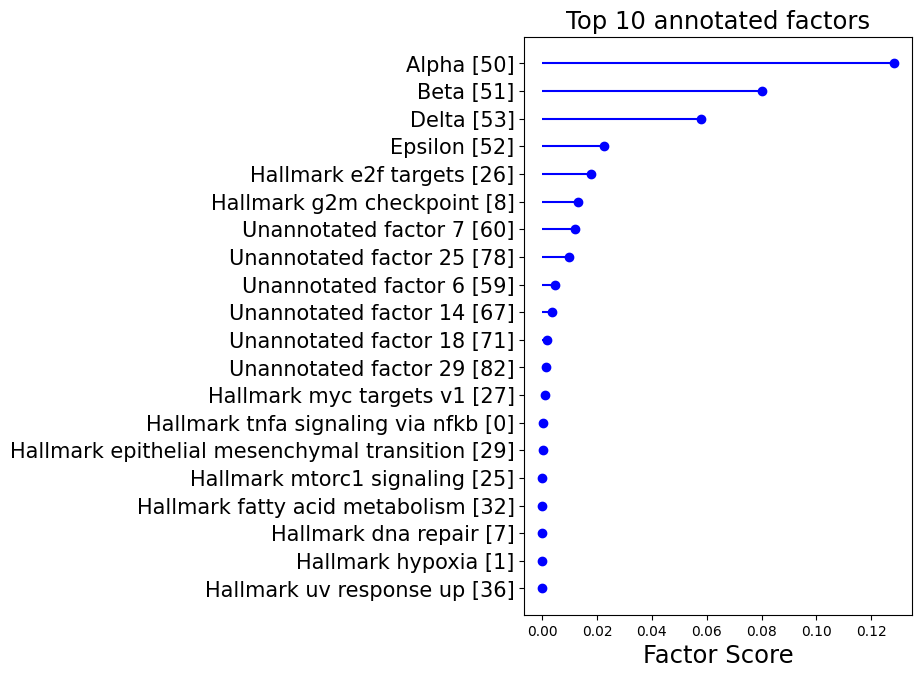

In [58]:
factor_importance_dict  = np.load(dr + '/factor_importance_scores_dict.npy', allow_pickle=True)[()]


factor_importance = factor_importance_dict['factor_importance']

highlighted_pathways =  []


pathway_names_plot = pathway_names_plot
factor_importance =factor_importance

factor_importance_only_ann = factor_importance #[:50]


index_asc_order = np.argsort(factor_importance_only_ann)[::-1][:20][::-1]

print([x for x in highlighted_pathways if x not in np.array(pathway_names_plot)[index_asc_order]])

plt.figure(figsize=(5, 7.5))
for i, idx in enumerate(index_asc_order):
    pathway_name = pathway_names_plot[idx]
    color = 'b' if pathway_name in highlighted_pathways else 'b'
    plt.stem([pathway_name], [factor_importance_only_ann[idx]], markerfmt=color+'o', linefmt=color+'-', orientation='horizontal')

#  plt.stem(np.array(pathway_names_plot)[index_asc_order], factor_importance[index_asc_order], markerfmt='ro', linefmt='b-', orientation='horizontal')
plt.title('Top 10 annotated factors', fontsize =17.5)
plt.xlabel('Factor Score', fontsize =17.5)
plt.tick_params(axis='y', which='major', labelsize=15)
            
red_patch = mpatches.Patch(color='red', label='Kown to be present')
blue_patch = mpatches.Patch(color='blue', label='Not known to be present')

#plt.legend(handles=[red_patch, blue_patch])

plt.show()

[]


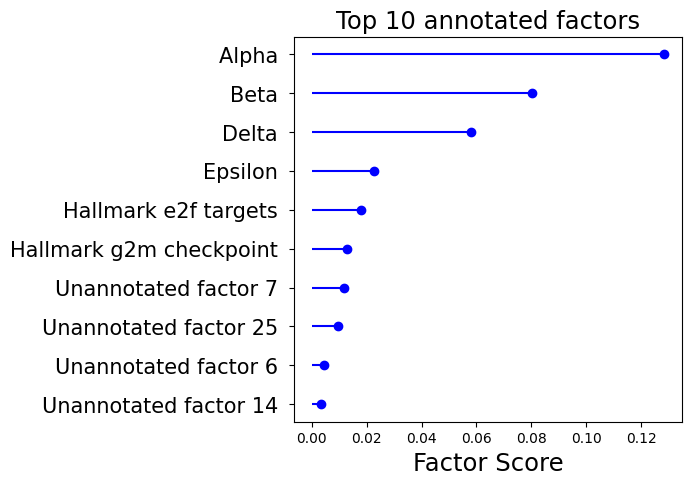

In [59]:
factor_importance_dict  = np.load(dr + '/factor_importance_scores_dict.npy', allow_pickle=True)[()]


factor_importance = factor_importance_dict['factor_importance']

highlighted_pathways =  []


pathway_names_plot = pathway_names_plot
factor_importance =factor_importance

factor_importance_only_ann = factor_importance #[:50]


index_asc_order = np.argsort(factor_importance_only_ann)[::-1][:10][::-1]

print([x for x in highlighted_pathways if x not in np.array(pathway_names_plot)[index_asc_order]])

plt.figure(figsize=(5, 5))
for i, idx in enumerate(index_asc_order):
    pathway_name = pathway_names_plot[idx]
    color = 'b' if pathway_name in highlighted_pathways else 'b'
    plt.stem([pathway_name.split('[')[0]], [factor_importance_only_ann[idx]], markerfmt=color+'o', linefmt=color+'-', orientation='horizontal')

#  plt.stem(np.array(pathway_names_plot)[index_asc_order], factor_importance[index_asc_order], markerfmt='ro', linefmt='b-', orientation='horizontal')
plt.title('Top 10 annotated factors', fontsize =17.5)
plt.xlabel('Factor Score', fontsize =17.5)
plt.tick_params(axis='y', which='major', labelsize=15)
            
red_patch = mpatches.Patch(color='red', label='Kown to be present')
blue_patch = mpatches.Patch(color='blue', label='Not known to be present')

#plt.legend(handles=[red_patch, blue_patch])

plt.show()

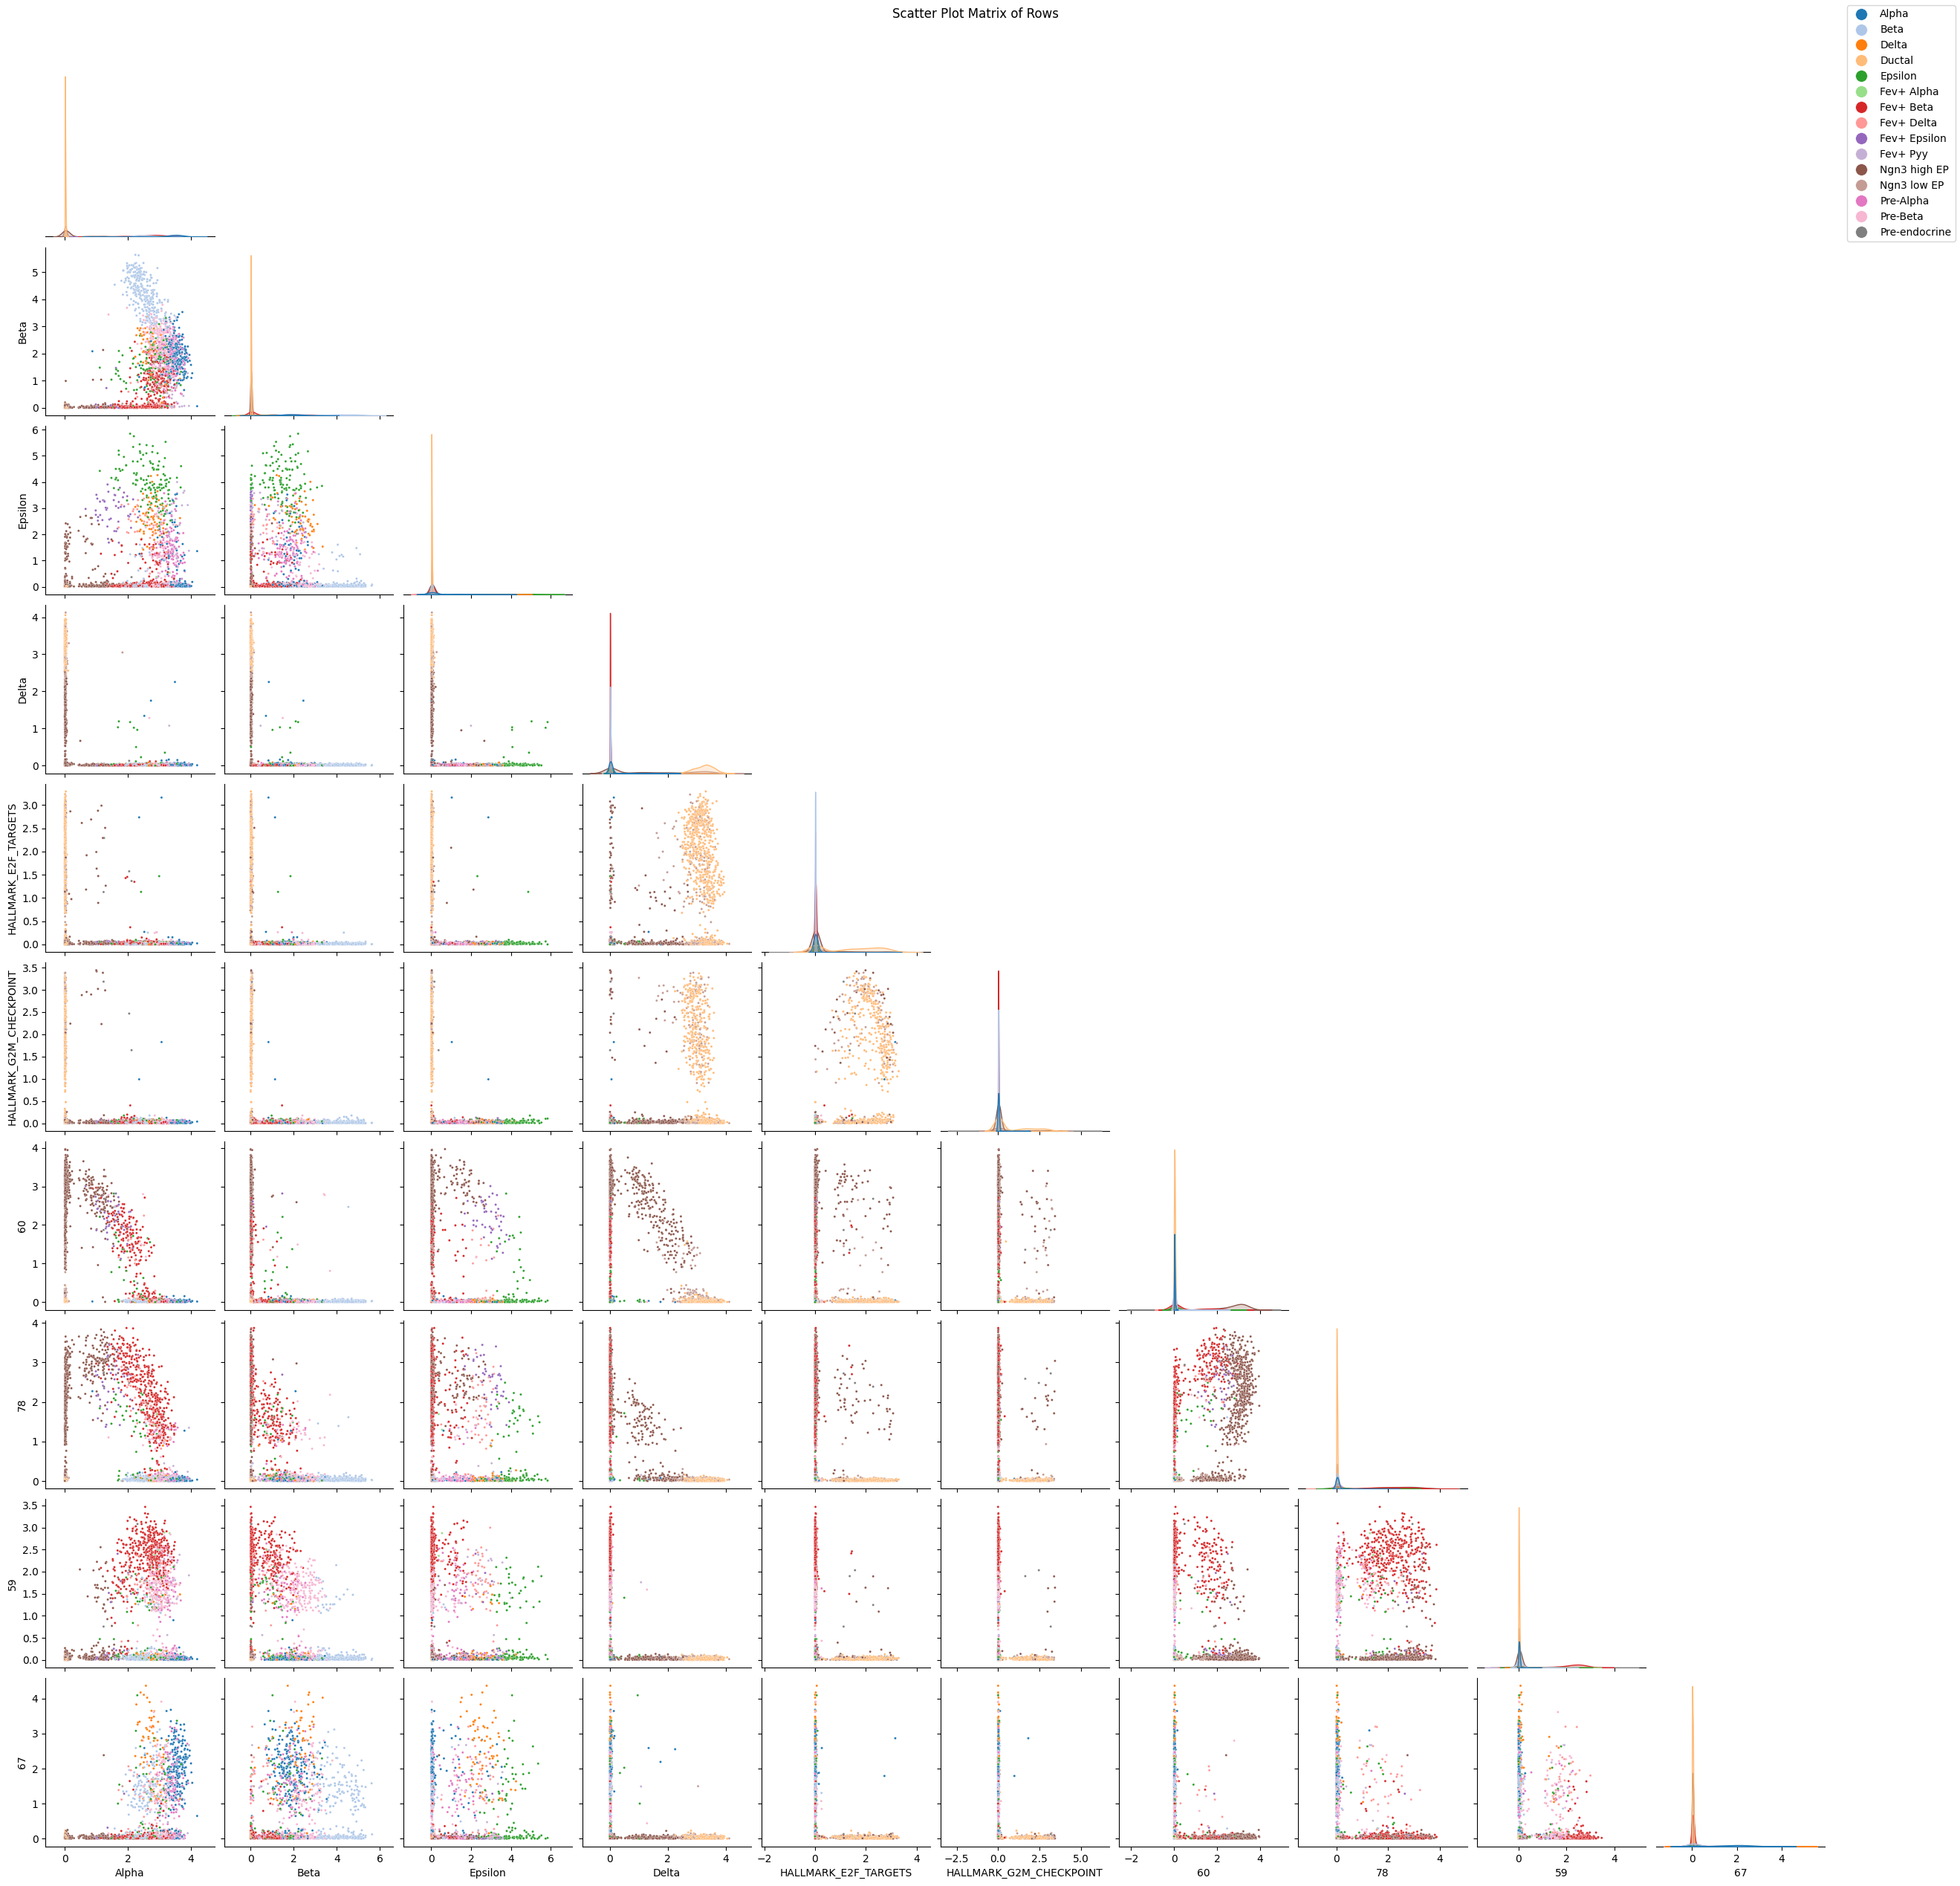

In [64]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

factor_ind = [50, 51, 52,53,26, 8, 60, 78, 59, 67]

transposed_matrix = learned_activations[factor_ind,:].T.astype(np.float16)

# Create a DataFrame where each column represents a row from the original matrix
df = pd.DataFrame(transposed_matrix, columns=[pathway_names[i] if i < num_ann else str(i) for i in factor_ind])
df['label'] = adata.obs['clusters_fine'].values
# Create the scatter plot matrix
pairplot = sns.pairplot(df, plot_kws={"s": 5.0}, hue = 'label', palette='tab20',corner=True)
pairplot._legend.remove()
plt.suptitle('Scatter Plot Matrix of Rows', y=1.02)
handles = pairplot._legend_data.values()
labels = pairplot._legend_data.keys()
pairplot.fig.legend(handles=handles, labels=labels, markerscale=5)
plt.show()


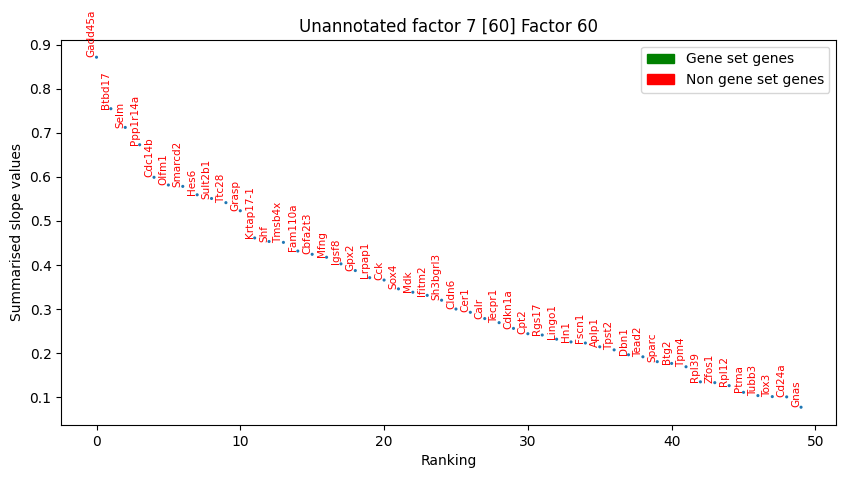

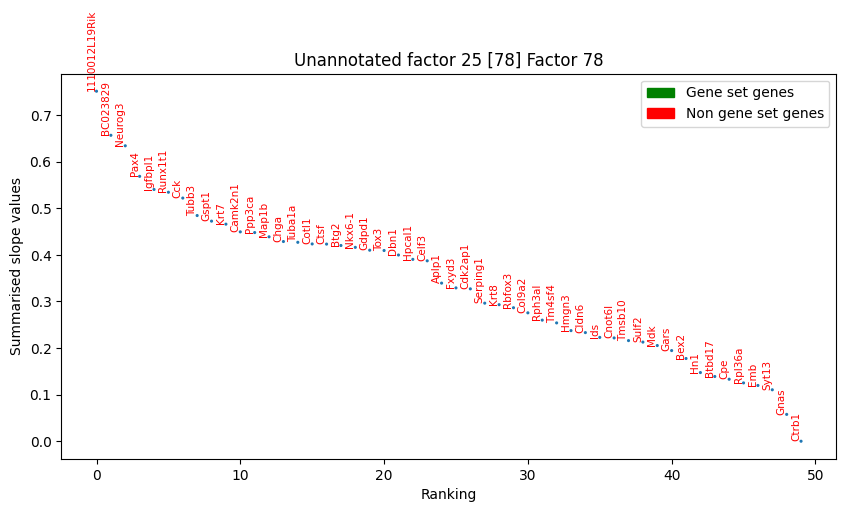

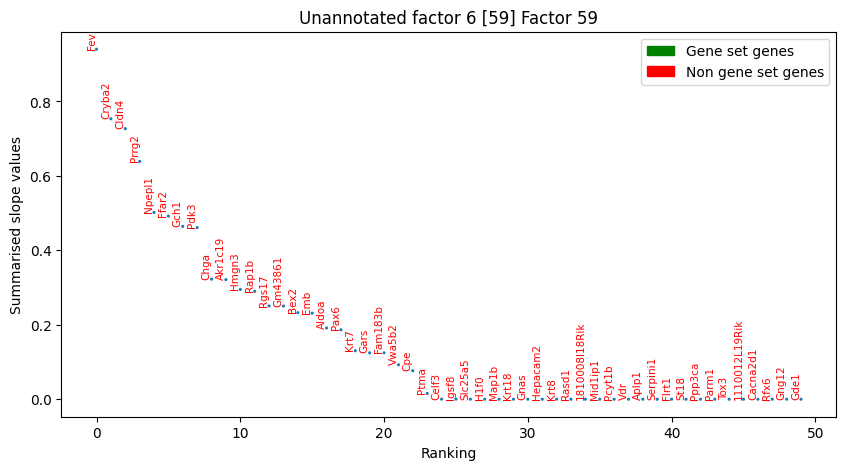

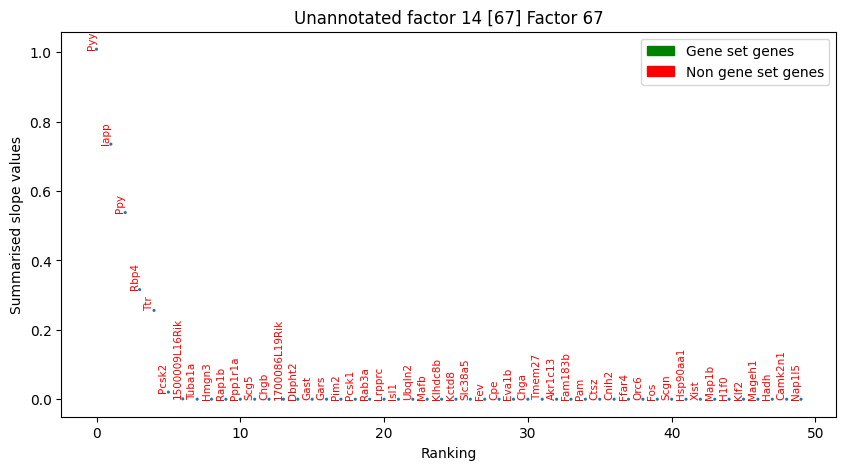

In [61]:



for fac in [60, 78, 59, 67]:

        factors = [fac]

        slopes_for_all_fac_lst = scvi_palava.spline_approach(factors = factors)
        slopes_for_all_fac  = {i:j for i, j  in zip(factors,slopes_for_all_fac_lst)}
        
        gene_set_fac = fac

        data_1 = np.quantile(abs(slopes_for_all_fac[fac]), q=0.95, axis=0)
        data_1_and_de_no_error = np.concatenate((data_1[None], pathways_bool[gene_set_fac].numpy()[None],gene_names.index.to_numpy()[None]), axis=0)
        data_1_and_de_no_error = sort_based_on_first_row(data_1_and_de_no_error)
    
        n_top_genes = 50
    
        y = data_1_and_de_no_error[0][:n_top_genes]
        x = np.array([i for i in range(n_top_genes)])
        
        plt.figure(figsize=(10, 5))
        plt.scatter(x, y, s = 5, edgecolor='none')
    
        # plotting pathway genes
        pathway_gene_ind = data_1_and_de_no_error[1][:n_top_genes] == 1
        #x_pathway = (data_1_and_de_no_error[1][:n_top_genes] * x)[pathway_gene_ind]
        #y_pathway = (np.ones(n_top_genes) * -0.05)[pathway_gene_ind]
        # plt.scatter(x_pathway, y_pathway, c='black', marker='|', label='In gene set',rasterized=True)
    
        plt.xlabel('Ranking')
        plt.ylabel('Summarised slope values')
        plt.title(pathway_names_plot[fac] + ' Factor ' + str(fac))
        
        #pdf_pages.savefig(bbox_inches='tight')
        
        
        top_gene_names = [element for element in data_1_and_de_no_error[2][:n_top_genes]]
        for i, txt in enumerate(top_gene_names):
             color = ['r', 'g'][int(data_1_and_de_no_error[1][i])]      
             plt.annotate(txt, (x[i], y[i]), ha = 'right', va = 'bottom', rotation = 90, fontsize = 7.5, color = color)
        geneset = mpatches.Patch(color='g', label='Gene set genes')
        nongeneset = mpatches.Patch(color='r', label='Non gene set genes')
        
        plt.legend(handles=[geneset, nongeneset])
        plt.show()
        plt.close()
        if False:
            count = 0 
            # for i, txt in enumerate([element for element in data_1_and_de_no_error[2][:n_top_genes]]):
            #     if 0 == int(data_1_and_de_no_error[1][i]):
            #         count += 1
            #         print('_'*25)
            #         print(txt)
            #         if count <  10:
            #             print(pathways_with(txt))
    
            index_for_mat_plor = [ np.where(adata.var.index.to_numpy() == data_1_and_de_no_error[2][:n_top_genes][i])[0][0] for i in range(n_top_genes)]
            
            ind_sort = np.argsort(latent[:,  fac])
            
            subset_for_matplot = adata_norm.X[:,index_for_mat_plor]/ adata_norm.X[:,index_for_mat_plor].max(axis =0)
            subset_for_matplot = median_smooth_rows(subset_for_matplot[ind_sort,:])
            plt.imshow(subset_for_matplot.T, aspect ='auto', interpolation ='none')
            plt.title('Cell type = '+ cell_type +' - Gene expression')
            plt.xlabel('Cells ordered by the factor')
            plt.colorbar()
            plt.show()
            plt.close()
        
            cell_type_genes[cell_type] = data_1_and_de_no_error[2][:n_top_genes]
        
        
        
            matrix = subset_for_matplot   # Example: 100 cells, 2000 genes
            matrix_transposed = matrix.T  # Now the shape is (genes, cells)
            
            # Step 1: Compute the k-nearest neighbors graph using sklearn
            knn_graph = kneighbors_graph(matrix_transposed, n_neighbors=10, mode='connectivity', include_self=False)
            
            # Step 2: Convert the KNN graph to an igraph object
            sources, targets = knn_graph.nonzero()  # Get the source and target node pairs
            edges = list(zip(sources, targets))     # Create edge list
            g = ig.Graph(edges=edges, directed=False)
            
            # Step 3: Perform Louvain clustering using igraph
            louvain_clusters = g.community_multilevel(resolution = 0.5)  # Use Louvain
            gene_clusters = louvain_clusters.membership  # Cluster labels for each gene
            
            # Step 4: Perform PCA on the transposed matrix (genes as rows)
            pca = PCA(n_components=2)
            pca_result = pca.fit_transform(matrix_transposed)
            
            # Step 5: Plot the PCA results, coloring by cluster labels
            plt.figure(figsize=(8, 6))
            sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=gene_clusters, palette='tab10', s=50)
            plt.title('PCA of Genes Colored by Louvain Clusters')
            plt.xlabel('PCA 1')
            plt.ylabel('PCA 2')
            plt.legend(title='Cluster')
        
        

                
                
            


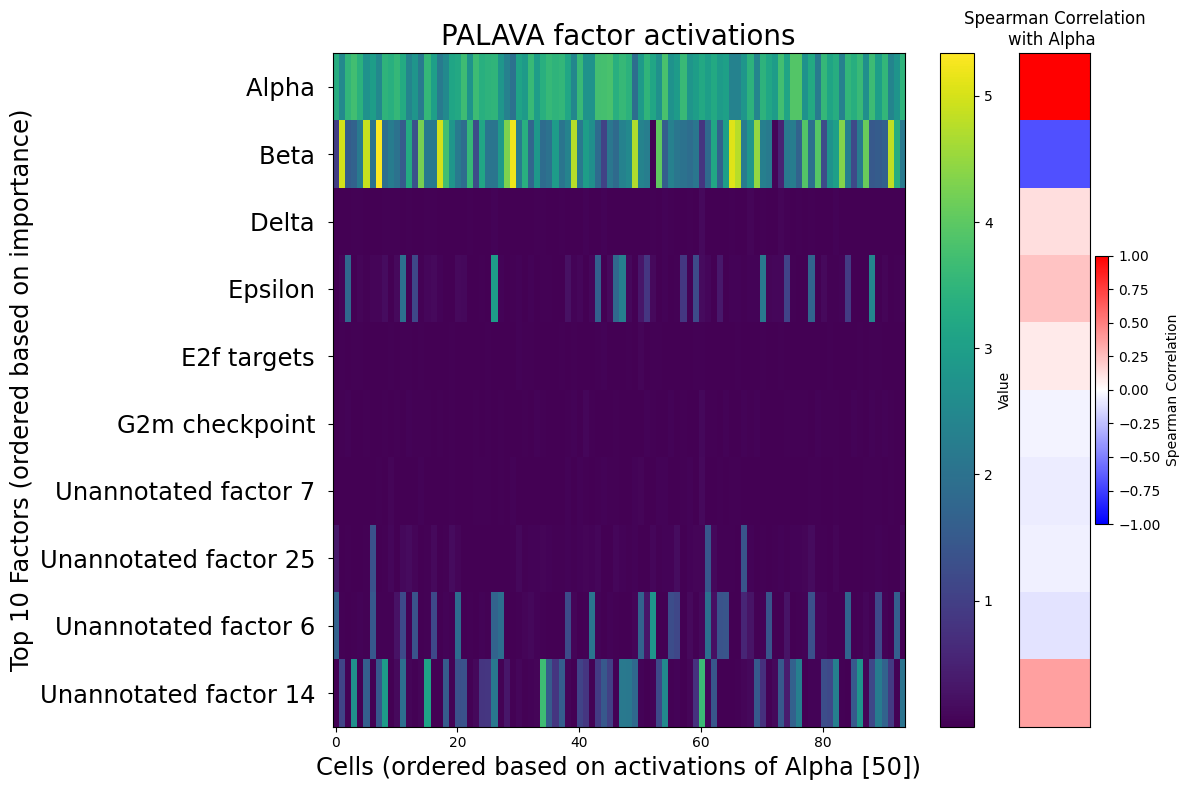

In [63]:
fac = 50
adata.obsm["X_scVI"] = scvi_palava.get_latent_representation()
latent = adata.obsm["X_scVI"][:,:(num_ann + num_unann)]
learned_activations = np.transpose(latent)
alpha =['Alpha', 'Pre-Alpha', 'Fev+ Alpha']
beta = ['Beta', 'Pre-Beta', 'Fev+ Beta']
cell_ind = adata.obs['clusters'].isin(alpha+beta).values

earned_activations_subset = learned_activations[:,cell_ind]

ind_sort = np.argsort(earned_activations_subset[:,  fac])
ind_sort = ind_sort
n_top = 10
subset_indx = np.argsort(factor_importance)[::-1][:n_top]
data = earned_activations_subset[subset_indx, :]

# Index of the row to compare with
pathway_names_plot_subset = [pathway_names_plot[i] for i in subset_indx]
# Extract the ith row
i = fac # Index of HEME factor 

target_row = earned_activations_subset[i, :]

# Compute Spearman's correlation for each row with the target row
correlations = np.array([spearmanr(target_row, row).correlation for row in data])

# Plot the data matrix and the Spearman correlation side by side, the tied observations receive the same average rank
fig, axes = plt.subplots(1, 2, figsize=(12, 8), gridspec_kw={'width_ratios': [4, 0.5]})

# Plot the data matrix on the left
im = axes[0].imshow(data[:,ind_sort], aspect='auto', cmap='viridis', interpolation='nearest')
axes[0].set_title("PALAVA factor activations", fontsize = 20)
axes[0].set_xlabel("Cells (ordered based on activations of "+pathway_names_plot[fac]+")", fontsize = 17.5)
axes[0].set_ylabel(f"Top {n_top} Factors (ordered based on importance)", fontsize = 17.5)
axes[0].set_yticks([i for i in range(len(pathway_names_plot_subset))], [i.split('[')[0].replace('Hallmark ', '').capitalize() for i in pathway_names_plot_subset], fontsize = 17.5)

plt.colorbar(im, ax=axes[0], label='Value')

# Plot the correlations as a single row on the right
correlation_matrix = correlations.reshape(-1, 1)  # Convert to a column vector for plotting
im_corr = axes[1].imshow(correlation_matrix, aspect='auto', cmap='bwr', interpolation='nearest' ,vmin=-1, vmax=1)
axes[1].set_title(f"Spearman Correlation\nwith " +pathway_names_plot[i].split('[')[0])
axes[1].set_xticks([])  # Remove x-axis ticks for clarity
axes[1].set_yticks([])  # Remove y-axis ticks for clarity
plt.colorbar(im_corr, ax=axes[1], label='Spearman Correlation')

# Adjust layout
plt.tight_layout()
plt.show()


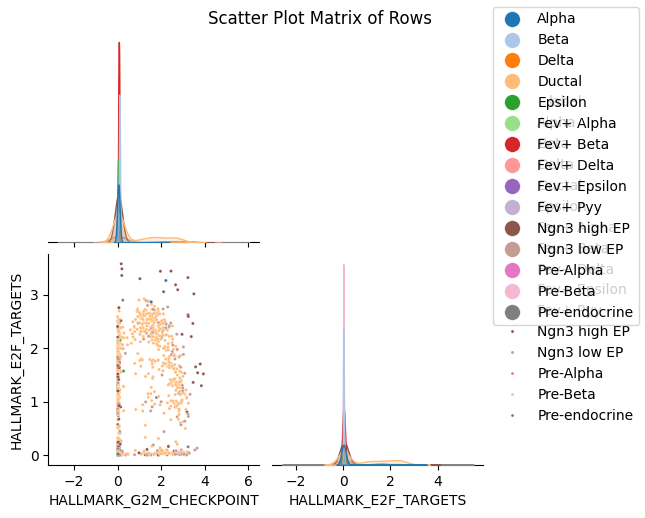

In [46]:


factor_ind = [8, 26]

transposed_matrix = learned_activations[factor_ind,:].T.astype(np.float16)

# Create a DataFrame where each column represents a row from the original matrix
df = pd.DataFrame(transposed_matrix, columns=[pathway_names[i] if i < num_ann else str(i) for i in factor_ind])
df['label'] = adata.obs['clusters_fine'].values
# Create the scatter plot matrix
pairplot = sns.pairplot(df, plot_kws={"s": 5.0}, hue = 'label', palette='tab20', corner=True)
plt.suptitle('Scatter Plot Matrix of Rows', y=1.02)
handles = pairplot._legend_data.values()
labels = pairplot._legend_data.keys()
pairplot.fig.legend(handles=handles, labels=labels, markerscale=5)
plt.show()


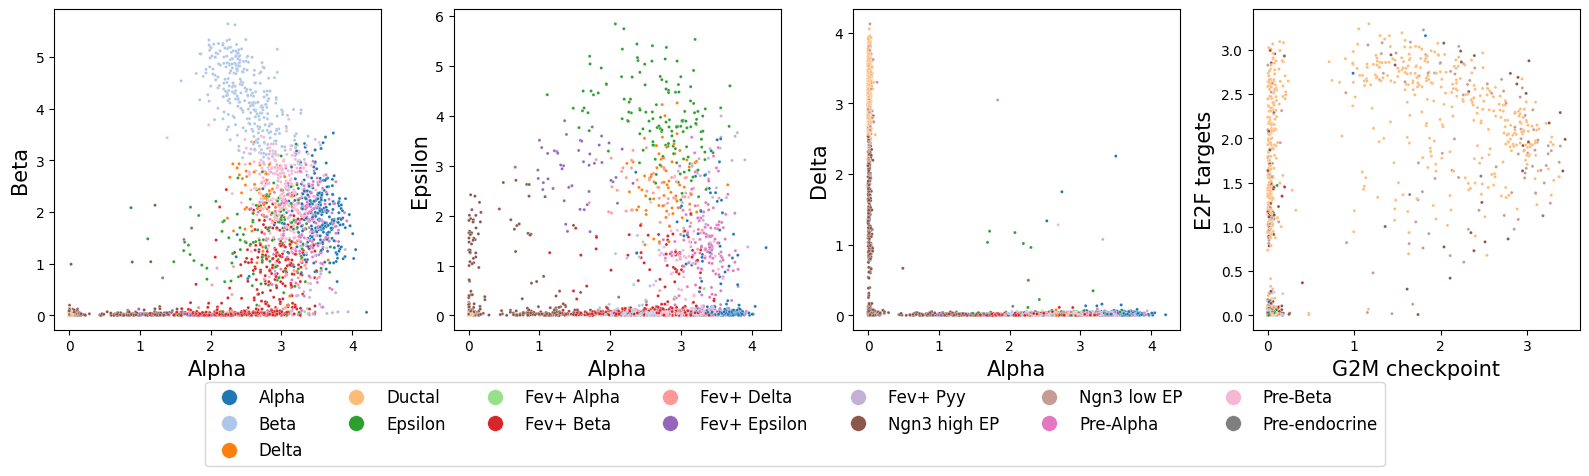

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def scatter_plot_grid(data, dim_pairs, ncols=3, label_array=None, palette='tab20', point_size=5.0, title=None):
    """
    Creates a grid of scatter plots based on dimension pairs with a legend for discrete labels.

    Parameters:
        data (np.ndarray): NumPy array with dimensions (dimensions, samples).
        dim_pairs (list of str): List of dimension pairs as strings, e.g., ['1,2', '8,6'].
        ncols (int): Number of columns in the grid.
        label_array (np.ndarray or None): Discrete labels for samples (length must match samples in data).
        palette (str): Color palette for the labels.
        point_size (float): Size of the points in the scatter plots.
        title (str): Title for the grid of scatter plots.
    """
    # Parse dimension pairs into a list of tuples
    dim_pairs = [tuple(map(int, pair.split(','))) for pair in dim_pairs]
    nplots = len(dim_pairs)
    nrows = int(np.ceil(nplots / ncols))  # Determine the number of rows

    # Create a grid of subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
    axes = axes.flatten()  # Flatten axes array for easier indexing

    for idx, (x_dim, y_dim) in enumerate(dim_pairs):
        ax = axes[idx]

        # Scatter plot for each pair of dimensions
        scatter_df = pd.DataFrame({
            f"Dimension {x_dim}": data[x_dim, :],
            f"Dimension {y_dim}": data[y_dim, :],
            "Label": label_array if label_array is not None else None
        })

        sns.scatterplot(
            data=scatter_df,
            x=f"Dimension {x_dim}",
            y=f"Dimension {y_dim}",
            hue="Label" if label_array is not None else None,
            palette=palette,
            s=point_size,
            ax=ax
        )
        x_label = axis_names_dict.get(x_dim, f"Dimension {x_dim}") if axis_names_dict else f"Dimension {x_dim}"
        y_label = axis_names_dict.get(y_dim, f"Dimension {y_dim}") if axis_names_dict else f"Dimension {y_dim}"
        ax.set_xlabel(x_label, fontsize  =15)
        ax.set_ylabel(y_label, fontsize  =15)
       
        if label_array is not None:
            ax.legend_.remove()  # Remove legend from individual plots

    # Turn off unused axes
    for idx in range(len(dim_pairs), len(axes)):
        axes[idx].axis('off')

    # Add a title
    if title:
        fig.suptitle(title, y=1.02, fontsize=16)

    # Add a custom legend
    if label_array is not None:
        unique_labels = np.unique(label_array)
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=len(unique_labels)/2,  fontsize  =12, markerscale =5.0, bbox_to_anchor=(0.5, -0.2))

    plt.tight_layout()
    plt.show()

axis_names_dict = {50: 'Alpha',  51 : 'Beta', 52: 'Epsilon',53:'Delta', 8:'G2M checkpoint', 26:'E2F targets'}

scatter_plot_grid(learned_activations, dim_pairs = ["50,51", "50,52", "50,53",'8,26'], ncols=4, label_array = adata_norm.obs['clusters_fine'],  palette='tab20', point_size=5.0, title=None)




In [24]:
pathway_names[53]

'Delta'

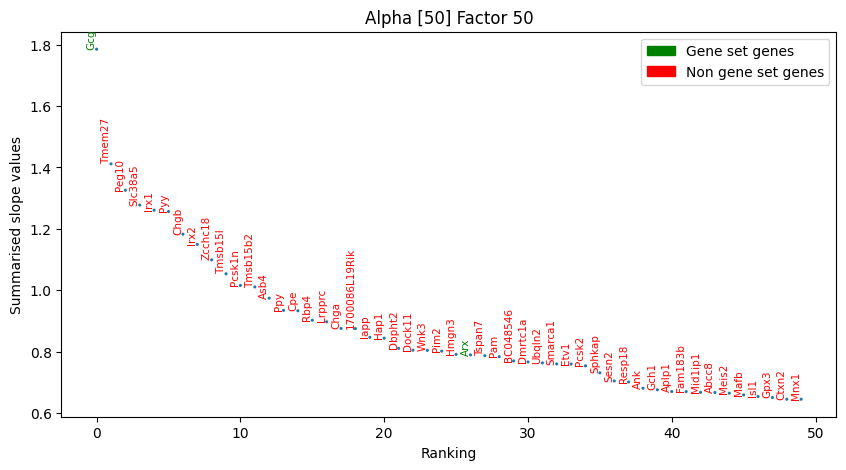

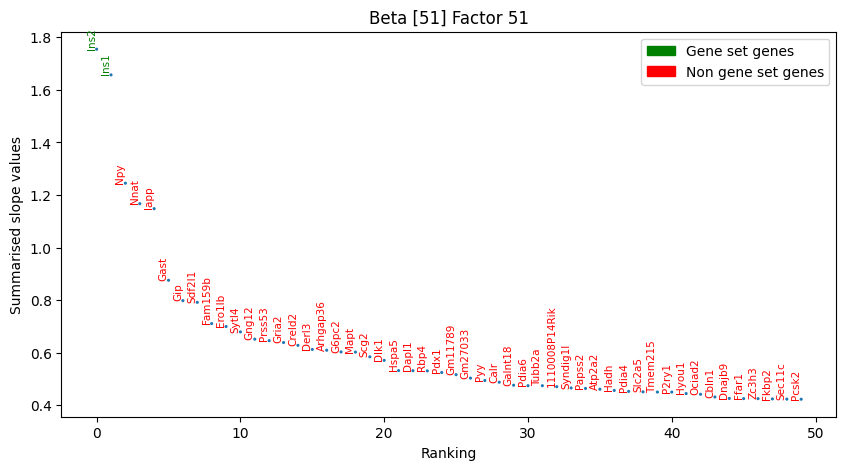

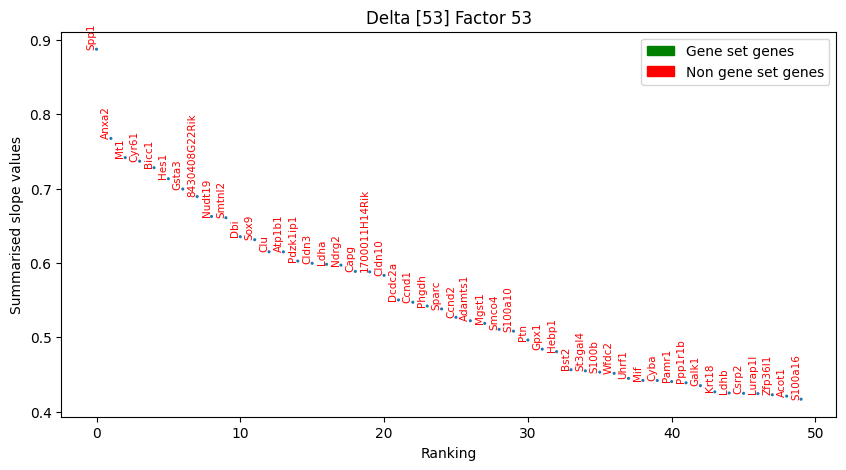

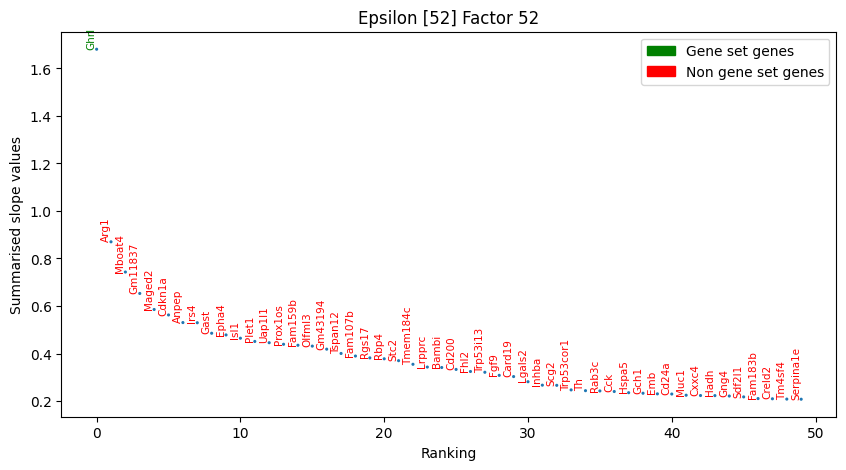

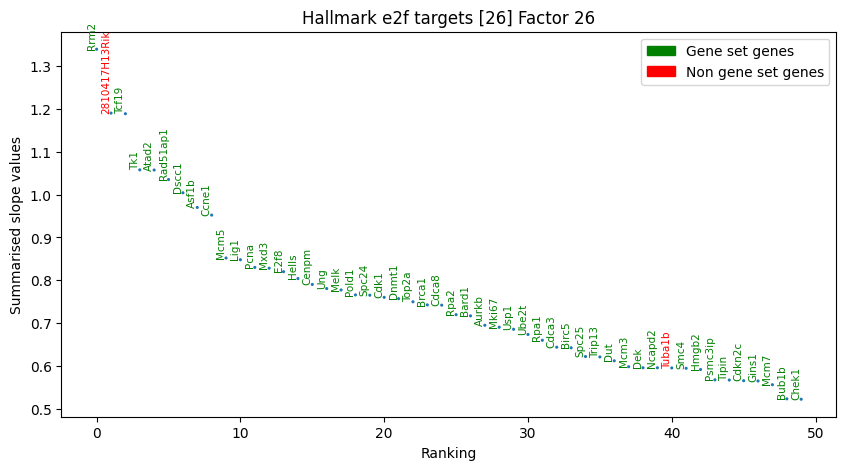

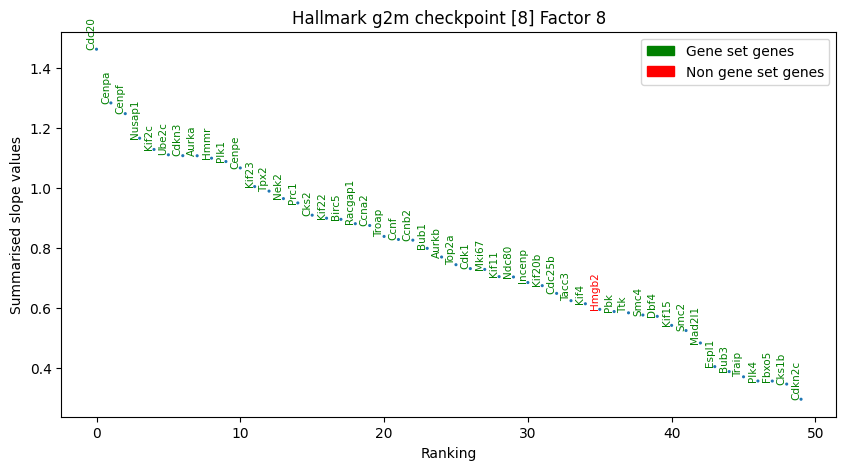

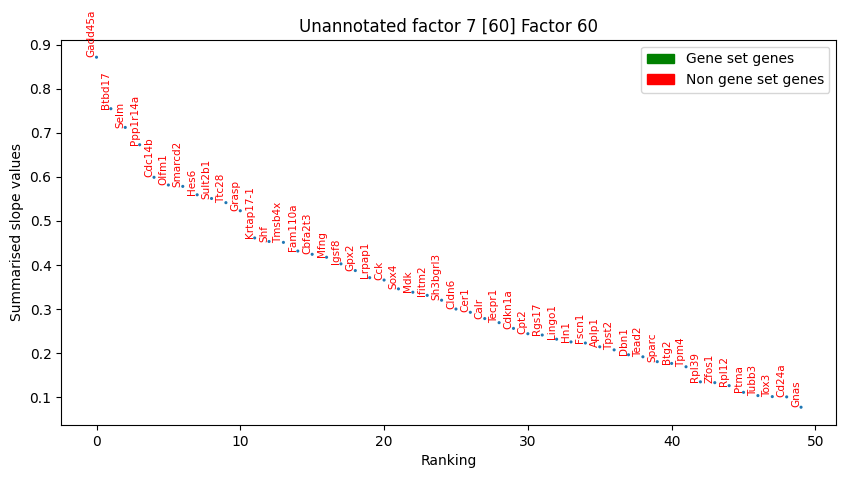

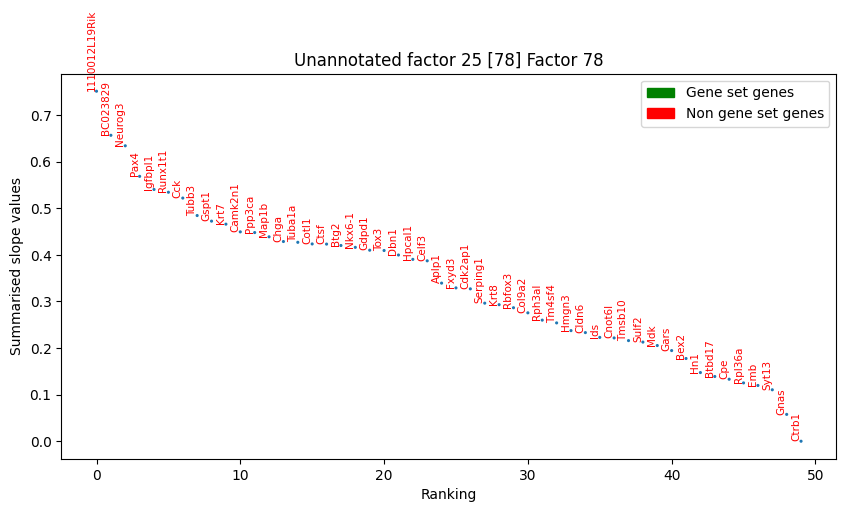

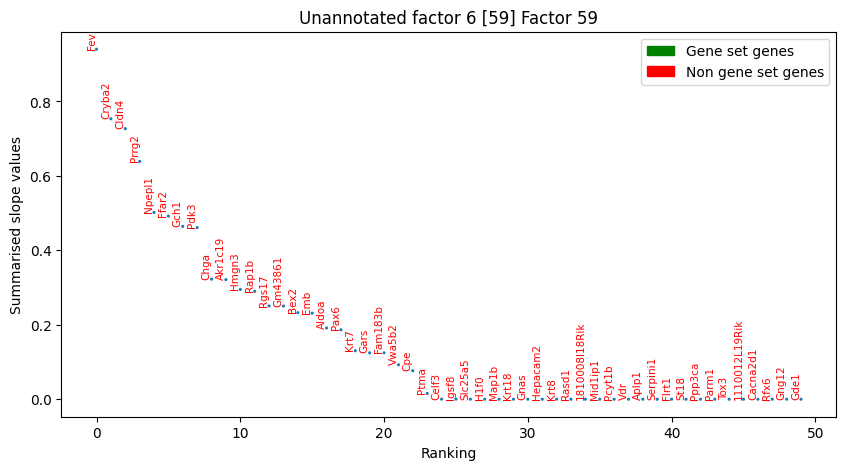

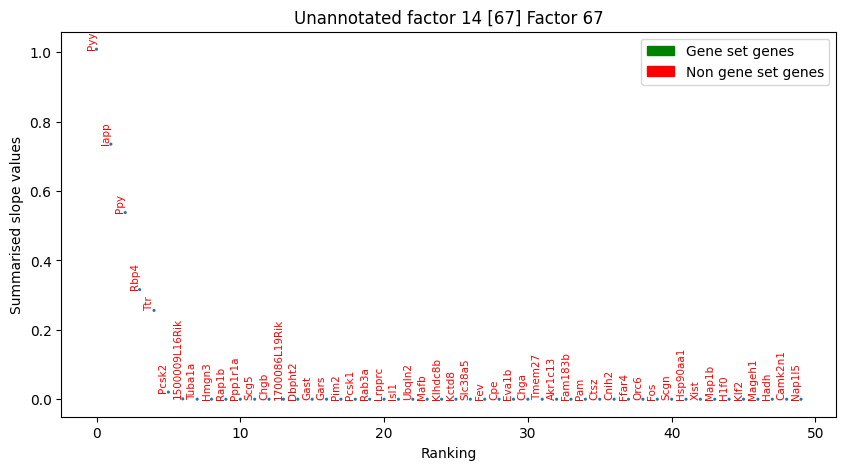

In [48]:



for fac in index_asc_order[::-1]:

        factors = [fac]

        slopes_for_all_fac_lst = scvi_palava.spline_approach(factors = factors)
        slopes_for_all_fac  = {i:j for i, j  in zip(factors,slopes_for_all_fac_lst)}
        
        gene_set_fac = fac

        data_1 = np.quantile(abs(slopes_for_all_fac[fac]), q=0.95, axis=0)
        data_1_and_de_no_error = np.concatenate((data_1[None], pathways_bool[gene_set_fac].numpy()[None],gene_names.index.to_numpy()[None]), axis=0)
        data_1_and_de_no_error = sort_based_on_first_row(data_1_and_de_no_error)
    
        n_top_genes = 50
    
        y = data_1_and_de_no_error[0][:n_top_genes]
        x = np.array([i for i in range(n_top_genes)])
        
        plt.figure(figsize=(10, 5))
        plt.scatter(x, y, s = 5, edgecolor='none')
    
        # plotting pathway genes
        pathway_gene_ind = data_1_and_de_no_error[1][:n_top_genes] == 1
        #x_pathway = (data_1_and_de_no_error[1][:n_top_genes] * x)[pathway_gene_ind]
        #y_pathway = (np.ones(n_top_genes) * -0.05)[pathway_gene_ind]
        # plt.scatter(x_pathway, y_pathway, c='black', marker='|', label='In gene set',rasterized=True)
    
        plt.xlabel('Ranking')
        plt.ylabel('Summarised slope values')
        plt.title(pathway_names_plot[fac] + ' Factor ' + str(fac))
        
        #pdf_pages.savefig(bbox_inches='tight')
        
        
        top_gene_names = [element for element in data_1_and_de_no_error[2][:n_top_genes]]
        for i, txt in enumerate(top_gene_names):
             color = ['r', 'g'][int(data_1_and_de_no_error[1][i])]      
             plt.annotate(txt, (x[i], y[i]), ha = 'right', va = 'bottom', rotation = 90, fontsize = 7.5, color = color)
        geneset = mpatches.Patch(color='g', label='Gene set genes')
        nongeneset = mpatches.Patch(color='r', label='Non gene set genes')
        
        plt.legend(handles=[geneset, nongeneset])
        plt.show()
        plt.close()
        if False:
            count = 0 
            # for i, txt in enumerate([element for element in data_1_and_de_no_error[2][:n_top_genes]]):
            #     if 0 == int(data_1_and_de_no_error[1][i]):
            #         count += 1
            #         print('_'*25)
            #         print(txt)
            #         if count <  10:
            #             print(pathways_with(txt))
    
            index_for_mat_plor = [ np.where(adata.var.index.to_numpy() == data_1_and_de_no_error[2][:n_top_genes][i])[0][0] for i in range(n_top_genes)]
            
            ind_sort = np.argsort(latent[:,  fac])
            
            subset_for_matplot = adata_norm.X[:,index_for_mat_plor]/ adata_norm.X[:,index_for_mat_plor].max(axis =0)
            subset_for_matplot = median_smooth_rows(subset_for_matplot[ind_sort,:])
            plt.imshow(subset_for_matplot.T, aspect ='auto', interpolation ='none')
            plt.title('Cell type = '+ cell_type +' - Gene expression')
            plt.xlabel('Cells ordered by the factor')
            plt.colorbar()
            plt.show()
            plt.close()
        
            cell_type_genes[cell_type] = data_1_and_de_no_error[2][:n_top_genes]
        
        
        
            matrix = subset_for_matplot   # Example: 100 cells, 2000 genes
            matrix_transposed = matrix.T  # Now the shape is (genes, cells)
            
            # Step 1: Compute the k-nearest neighbors graph using sklearn
            knn_graph = kneighbors_graph(matrix_transposed, n_neighbors=10, mode='connectivity', include_self=False)
            
            # Step 2: Convert the KNN graph to an igraph object
            sources, targets = knn_graph.nonzero()  # Get the source and target node pairs
            edges = list(zip(sources, targets))     # Create edge list
            g = ig.Graph(edges=edges, directed=False)
            
            # Step 3: Perform Louvain clustering using igraph
            louvain_clusters = g.community_multilevel(resolution = 0.5)  # Use Louvain
            gene_clusters = louvain_clusters.membership  # Cluster labels for each gene
            
            # Step 4: Perform PCA on the transposed matrix (genes as rows)
            pca = PCA(n_components=2)
            pca_result = pca.fit_transform(matrix_transposed)
            
            # Step 5: Plot the PCA results, coloring by cluster labels
            plt.figure(figsize=(8, 6))
            sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=gene_clusters, palette='tab10', s=50)
            plt.title('PCA of Genes Colored by Louvain Clusters')
            plt.xlabel('PCA 1')
            plt.ylabel('PCA 2')
            plt.legend(title='Cluster')
        
        

                
                
            
